[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/juliopez/Taller-Fundamentos-Data-Science-Python/blob/main/Machine_Learning_2026/03_Notebooks/NB01_Introduccion_Redes_Neuronales.ipynb)
# NB01 — Introducción a redes neuronales
**Correspondencia: Semanas 3–4**


## 1. Preparación del entorno


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 2. Dataset para el primer modelo

Trabajaremos con un problema de clasificación binaria sencillo. El objetivo es concentrarnos en el flujo fundamental de una red neuronal: **datos → modelo → entrenamiento → evaluación → predicción**.


### 💡 ¿De dónde provienen los datos de esta práctica?

En este ejercicio **no descargaremos un archivo CSV**. Utilizaremos `make_moons()`, una función de **Scikit-learn** que genera un conjunto de datos **sintético** especialmente útil para practicar clasificación binaria.

- `X` contendrá las **variables de entrada** (*features*).
- `y` contendrá la **clase que queremos predecir** (*target*).
- `n_samples=1000` indica cuántas observaciones se generarán.
- `noise=0.20` agrega variabilidad para que el problema no sea perfectamente separable.
- `random_state=42` permite obtener los mismos datos cada vez que ejecutamos el notebook.

#### 🔄 ¿Y si quisiera trabajar con mis propios datos?

En un proyecto real, `X` e `y` pueden provenir de un CSV, una base de datos, una API u otra fuente. Por ejemplo:

```python
import pandas as pd

df = pd.read_csv("mis_datos.csv")
X = df[["variable_1", "variable_2"]]
y = df["variable_objetivo"]
```

La fuente de datos cambia, pero el flujo conceptual continúa siendo similar: **cargar → preparar → separar → construir → entrenar → evaluar → predecir**.


### 🧠 ¿Por qué separar entrenamiento y prueba?

No debemos evaluar el modelo utilizando exactamente los mismos datos con los que aprendió. Por eso dividimos el conjunto de datos:

- **Entrenamiento (`train`)**: datos utilizados para aprender los parámetros del modelo.
- **Prueba (`test`)**: datos reservados para evaluar finalmente cómo se comporta frente a observaciones que no utilizó para aprender.

`stratify=y` procura mantener aproximadamente la misma proporción de clases en ambos subconjuntos. `random_state` hace reproducible la división.

> **Importante:** el conjunto de prueba debe permanecer fuera del proceso de entrenamiento.


In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=1000,
    noise=0.20,
    random_state=42
)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Clases:", np.unique(y))


Dimensiones de X: (1000, 2)
Dimensiones de y: (1000,)
Clases: [0 1]


## 3. Exploración de los datos


### 🔎 Antes de visualizar: ¿qué estamos observando?

Aquí queremos comprender la estructura del problema antes de entrenar una red neuronal. Si `X` posee dos columnas, `X[:, 0]` representa la primera característica y `X[:, 1]` la segunda. El parámetro `c=y` utiliza la clase objetivo para diferenciar visualmente los grupos.

Esta visualización es posible porque tenemos solamente dos características. Con decenas o cientos de variables necesitaríamos otras estrategias de exploración o reducción de dimensionalidad.


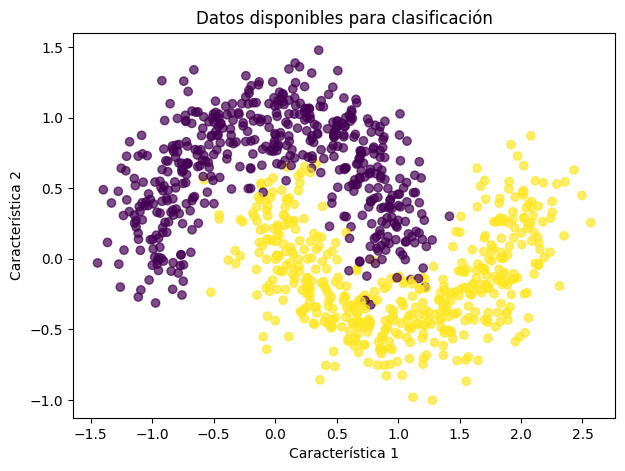

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.7)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Datos disponibles para clasificación")
plt.show()


## 4. División de los datos

Separaremos los datos en conjuntos de entrenamiento y prueba.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (800, 2)
Prueba: (200, 2)


## 5. Construcción de una red neuronal

La red utilizará capas densas. Cada neurona recibe entradas, aplica pesos y sesgo, y posteriormente una función de activación.


### 🧩 Del concepto al código: construcción de la arquitectura

En esta sección **construimos la red**, pero todavía no la entrenamos.

- `Sequential` organiza las capas una después de otra.
- `Dense` crea una capa totalmente conectada.
- El número dentro de `Dense(...)` indica sus **unidades o neuronas**.
- `activation` especifica la función de activación.
- La forma de entrada describe cuántos valores recibe cada observación.

Los tamaños de las capas y varias decisiones de arquitectura son **hiperparámetros** definidos por quien diseña el modelo. En cambio, los **pesos y sesgos** serán aprendidos posteriormente durante el entrenamiento.

---

💡 **Conexión:** utiliza el simulador *Explorador de decisiones de una Red Neuronal* para comparar `Dense` con otras capas y revisar alternativas de activación.

👉 [Abrir Simulador Interactivo de Redes Neuronales](https://juliopez.github.io/Taller-Fundamentos-Data-Science-Python/Simulador_Redes_Neuronales.html)

---

In [5]:
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Compilación del modelo

Definiremos tres elementos fundamentales:

- **Función de pérdida:** mide el error del modelo.
- **Optimizador:** actualiza los pesos.
- **Métrica:** permite observar el desempeño durante entrenamiento.


### ⚙️ Compilar no significa entrenar

`compile()` configura **cómo aprenderá y cómo observaremos el desempeño** del modelo.

- **Optimizer**: determina cómo se actualizarán los parámetros aprendidos.
- **Loss**: cuantifica el error que el entrenamiento intentará reducir.
- **Metrics**: permiten observar medidas de desempeño comprensibles, como `accuracy`.

Una idea fundamental es distinguir:

**Arquitectura del modelo ≠ configuración del aprendizaje ≠ entrenamiento**

El entrenamiento comenzará recién cuando ejecutemos `fit()`.


In [6]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


## 7. Entrenamiento

Durante cada época, la red procesa los datos, calcula el error y actualiza sus pesos mediante el proceso de aprendizaje.


### 🏋️ Ahora sí: comienza el entrenamiento

`fit()` hace que la red utilice los datos de entrenamiento para ajustar sus **pesos y sesgos**.

Conceptos importantes:

- **Epoch**: una pasada completa por los datos de entrenamiento.
- **Batch size**: cantidad de observaciones procesadas antes de realizar una actualización.
- **Validation split**: reserva una parte de los datos de entrenamiento para observar el comportamiento del modelo durante el aprendizaje.

Por tanto, podemos pensar en tres roles diferentes:

**TRAIN → aprender parámetros**  
**VALIDATION → observar y ajustar decisiones de modelado**  
**TEST → evaluación final**

> Los valores de `epochs`, `batch_size` y otras configuraciones no son universales: son hiperparámetros que pueden experimentarse y ajustarse.


In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=40,
    batch_size=32,
    verbose=1
)


Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5547 - loss: 0.6921 - val_accuracy: 0.7437 - val_loss: 0.6873
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6672 - loss: 0.6856 - val_accuracy: 0.6875 - val_loss: 0.6790
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6547 - loss: 0.6782 - val_accuracy: 0.7375 - val_loss: 0.6687
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6891 - loss: 0.6691 - val_accuracy: 0.7375 - val_loss: 0.6553
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7094 - loss: 0.6570 - val_accuracy: 0.7375 - val_loss: 0.6388
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7156 - loss: 0.6420 - val_accuracy: 0.7500 - val_loss: 0.6196
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7203 - loss: 0.6251 - val_accuracy: 0.7500 - val_loss: 0.5962
Epoch 8/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7203 - loss: 0.6054 - val_accuracy: 0.7500 - val_los

## 8. Curvas de aprendizaje


### 📈 ¿Cómo interpretar las curvas de aprendizaje?

El historial de `fit()` permite observar cómo cambia el desempeño a través de las épocas.

Compare especialmente **entrenamiento** y **validación**:

- Si ambos mejoran, el modelo probablemente está aprendiendo.
- Si entrenamiento continúa mejorando pero validación empeora, puede aparecer una señal de **sobreajuste**.
- Si ambos muestran desempeño bajo, la arquitectura, los datos o el proceso de entrenamiento podrían requerir revisión.

No busque solamente “la curva más alta”: observe también la **diferencia entre entrenamiento y validación**.


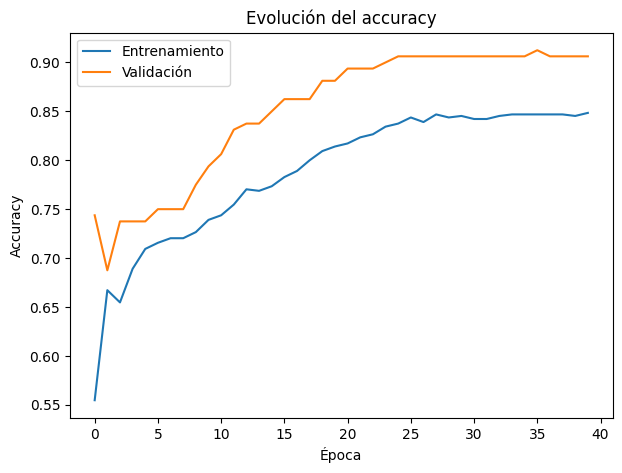

In [8]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(7, 5))
plt.plot(history_df["accuracy"], label="Entrenamiento")
plt.plot(history_df["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Evolución del accuracy")
plt.legend()
plt.show()


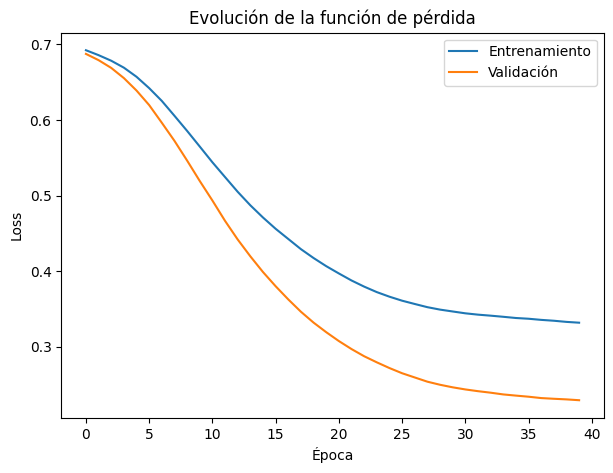

In [9]:
plt.figure(figsize=(7, 5))
plt.plot(history_df["loss"], label="Entrenamiento")
plt.plot(history_df["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolución de la función de pérdida")
plt.legend()
plt.show()


## 9. Evaluación con datos no utilizados para entrenamiento


### 🎯 Evaluación final con datos no utilizados para aprender

Ahora utilizamos el conjunto `test`. Su función es estimar el comportamiento del modelo sobre datos que permanecieron fuera del entrenamiento.

Esta separación es importante porque un modelo puede obtener excelentes resultados sobre los ejemplos que ya utilizó y, aun así, generalizar deficientemente.

> El conjunto de prueba no debería utilizarse repetidamente para decidir cada modificación del modelo, porque terminaríamos ajustando indirectamente nuestras decisiones a esos datos.


In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_accuracy:.4f}")


Loss en test: 0.2386
Accuracy en test: 0.8950


## 10. Realizar predicciones


### 🔮 Predicción: la red no siempre entrega directamente una clase

En clasificación binaria con una salida `sigmoid`, `predict()` normalmente entrega valores continuos entre 0 y 1, por ejemplo:

`0.18`, `0.63`, `0.91`

Para transformarlos en clases necesitamos establecer un **umbral**. Con un umbral de `0.5`:

- valor `< 0.5` → clase 0
- valor `≥ 0.5` → clase 1

El valor `0.5` es una decisión frecuente, pero **no constituye una regla universal**. Dependiendo del problema y del costo de falsos positivos o falsos negativos, el umbral puede modificarse.


In [11]:
probabilidades = model.predict(X_test[:10], verbose=0).flatten()
predicciones = (probabilidades >= 0.5).astype(int)

resultados = pd.DataFrame({
    "Probabilidad": probabilidades,
    "Clase_predicha": predicciones,
    "Clase_real": y_test[:10]
})

resultados


,Probabilidad,Clase_predicha,Clase_real
0,0.374328,0,1
1,0.081575,0,0
2,0.069513,0,0
3,0.074607,0,0
4,0.910470,1,1
5,0.476929,0,1
6,0.925018,1,1
7,0.819505,1,1
8,0.112945,0,0
9,0.170351,0,0


## 11. Visualización de la clasificación aprendida


### 🗺️ Frontera de decisión: una visualización, no una etapa obligatoria

El siguiente código crea una malla de puntos artificiales y solicita al modelo una predicción para cada uno. Esto permite visualizar las regiones del espacio que la red asignaría a cada clase.

Funciones como `meshgrid()` y `contourf()` se utilizan aquí principalmente con fines de **visualización pedagógica**. No son requisitos para entrenar una red neuronal.

Además, esta representación resulta especialmente cómoda porque el ejemplo posee solamente **dos variables de entrada**.


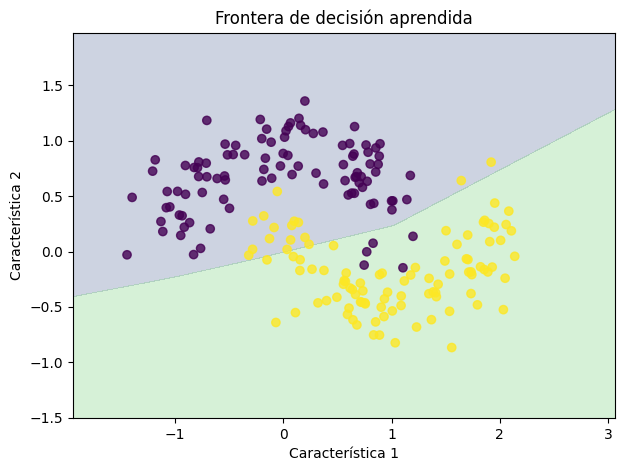

In [12]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
zz = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, zz, levels=[0, 0.5, 1], alpha=0.25)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, alpha=0.8)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Frontera de decisión aprendida")
plt.show()


## 12. Experimentación

Modifique **un elemento a la vez** y vuelva a entrenar el modelo.

Pruebe, por ejemplo:

- cantidad de neuronas;
- cantidad de capas ocultas;
- función de activación;
- número de épocas;
- tamaño del batch.

Registre el cambio realizado y compare el resultado con el modelo original.


In [ ]:
# Modelo experimental
modelo_experimental = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

modelo_experimental.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

historial_experimental = modelo_experimental.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=40,
    batch_size=32,
    verbose=0
)

loss_exp, acc_exp = modelo_experimental.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Accuracy modelo experimental: {acc_exp:.4f}")


## 13. Comparación de resultados


In [ ]:
comparacion = pd.DataFrame({
    "Modelo": ["Modelo inicial", "Modelo experimental"],
    "Accuracy_test": [test_accuracy, acc_exp]
})

comparacion


## 14. Actividad

Responda a partir de los resultados obtenidos:

1. ¿Qué función cumplen las capas ocultas de la red?
2. ¿Qué función cumple la capa de salida?
3. ¿Qué representa la función de pérdida?
4. ¿Qué diferencia observa entre entrenamiento, validación y prueba?
5. ¿El cambio realizado en el modelo experimental mejoró el desempeño?
6. ¿Qué modificación probaría a continuación y por qué?


## 15. Base para la próxima Evaluación

Utilice el flujo desarrollado en este notebook como referencia para construir el **prototipo funcional inicial** del proyecto integrador:

**datos → arquitectura → compilación → entrenamiento → validación → predicción**.


### 🧪 Experimentar con el modelo: cambie una decisión a la vez

Cuando compare arquitecturas o hiperparámetros, procure modificar **una decisión principal a la vez**. Por ejemplo, compare primero una capa de 8 unidades con una de 16 manteniendo las demás condiciones.

Esto ayuda a responder una pregunta fundamental: **¿qué cambio pudo producir la diferencia observada?**

Recuerde también que una mejora en `accuracy` no siempre significa que el nuevo modelo sea mejor para cualquier problema. En aplicaciones reales pueden ser relevantes otras métricas como `precision`, `recall`, AUC o medidas específicas del dominio.

### 🔄 Transferencia a un conjunto de datos propio

Cuando utilice datos propios, no necesita copiar literalmente este ejemplo. Identifique qué partes deben adaptarse:

1. **Origen de los datos:** reemplazar `make_moons()` por CSV, base de datos, API, etc.
2. **Variables predictoras (`X`) y objetivo (`y`)**: definirlas según el problema.
3. **Preparación:** tratar faltantes, categorías, escalas y otras necesidades.
4. **Entrada de la red:** adaptar `input_shape` al número y estructura de características.
5. **Salida, activación y loss:** escogerlas según clasificación binaria, multiclase o regresión.
6. **Métricas:** seleccionar las que realmente permitan evaluar el objetivo del problema.

La idea central del notebook no es memorizar este código, sino comprender un **flujo reutilizable de Machine Learning**.
